# <font color='blue'> Module 4: Working with Data in Python </font>

## <font color='grey'> Chapter 1: Reading and Writing Files with 'Open'</font>

### Reading files with 'open'

In [51]:
# Open a file in read ('r') mode with Python's open function
myFile = open("example.txt", 'r')

In [52]:
# Open a file using 'with' statement
with open("example.txt", 'r') as myFile:
    file_content = myFile.read()
    print(file_content)                      # Print the contents

UK is a European Country.
London is a cosmopolitan city.
Wales is beautiful.
Edinburgh is a historical city.


### Benefits of using 'with' to open a file
- Efficient and Automatic Resource management:
    * When you exit the 'with' block you automatically close a file even if an error has occurred thus freeing memory.
- Clean and Consise:
    * You don't need to call <code>close()</code> and the code is easy to read.
 

### Reading content Line-by-Line

In [53]:
# reading line-by-line using 'readline()'
with open("example.txt", 'r') as file:
    #file_content = file.read()    # If you run this python will read the entire file and the pointer will be at the end of file

    first_line = file.readline()   # first instance reads the first line
    second_line = file.readline()  # second call will read the second line and so on

    print(first_line)
    print(second_line)

    file.close()  # not needed, because the file will close automatically once you exit the loop

UK is a European Country.

London is a cosmopolitan city.



### Reading the Contents Using Loop

In [54]:
# reading the entire file using while loop:
with open("example.txt", 'r') as file:
    while True:
        current_line = file.readline()
    
        if not current_line:
            break
        print(current_line)

UK is a European Country.

London is a cosmopolitan city.

Wales is beautiful.

Edinburgh is a historical city.


### Writing to a File

In [55]:
# writing to a new file
with open("example2.txt", 'w') as file:
    file.write("Himalayas are the tallest mountain range.\n")
    file.write("Russia is the largest country by area.\n")

In [56]:
# verify that the contents is actually dumped to the output file
with open("example2.txt", 'r') as file:
    while True:
        current_line = file.readline()
    
        if not current_line:
            break
        print(current_line)

Himalayas are the tallest mountain range.

Russia is the largest country by area.



## <font color='grey'> Chapter 2: Pandas</font>
Pandas is one of the most popular open-source Python libraries used for data science and analytics. Think of it as Excel on steroids inside your Python environment. It provides fast, flexible, and expressive data structures designed to make working with "relational" or "labeled" data both easy and intuitive.

It is heavily used for data cleaning, data transformation, exploration, and analysis tasks.

At the core of Pandas are two primary data structures: Series and DataFrames.

### Series
A Series is a one-dimensional array-like object. It can hold any data type (integers, strings, floating-point numbers, Python objects, etc.).

The defining feature of a Series is that it has a data index, which labels each element. If you don't specify an index, Pandas will automatically create one starting from 0.  
*<u>Analogy</u>: Think of a Series as a single column in an Excel spreadsheet, or a typed-up list where every item has a specific row label.*

In [57]:
# Creating a series example
import pandas as pd

# Create simple series
goals = pd.Series([2,6,2,4,1,5], index=["Brazil", "Chile", "Spain", "England", "France", "Germany"])
print(goals)

Brazil     2
Chile      6
Spain      2
England    4
France     1
Germany    5
dtype: int64


### DataFrames

A DataFrame is a two-dimensional, size-mutable, and potentially heterogeneous tabular data structure. In plain English: it is a table with rows and columns, just like an Excel spreadsheet or a SQL table.

- *<u>Analogy</u>:* If a Series is a single column, a **DataFrame is the entire spreadsheet**.
- *<u>Relationship to Series</u>:* You can also think of a DataFrame as a **container for multiple Series objects that share the same index**.

In [58]:
# Creating DataFrame from a Dictionary

data = {
    'City': ['London', 'Paris', 'Berlin'],
    'Temperature': [18, 22, 19],
    'Humidity': [75, 60, 65]
}

df = pd.DataFrame(data)
print(df)

     City  Temperature  Humidity
0  London           18        75
1   Paris           22        60
2  Berlin           19        65


### Accessing a Column or Multiple Columns in a DataFrame

In [59]:
# Accessing a column
myTemp = df[['Temperature']]
print(myTemp)

   Temperature
0           18
1           22
2           19


In [60]:
# Check type of each entry
print(type(myTemp))

<class 'pandas.DataFrame'>


In [61]:
# Accessing multiple columns
multCol = df[['Temperature', 'Humidity']]
print(multCol)

   Temperature  Humidity
0           18        75
1           22        60
2           19        65


### Accessing columns as 'Series' rather than 'DataFrames'
**If you use double square brackes i.e. [[\<some_key\>]] then the pandas will return a DataFrame.**  
**But if you use a single square bracket i.e. [\<some_key\>] then pandas will return a Series.**  
e.g.

In [62]:
# Column as DataFrame
myTemp_df = df[['Temperature']]
myTemp_sr = df['Temperature']
print(type(myTemp_df))
print(type(myTemp_sr))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### <code>loc[]</code> and <code>iloc[]</code> Functions

In Pandas, <code>.loc[]</code> and <code>.iloc[]</code> are the two primary properties used to select, filter, and slice data from a DataFrame.

The easiest way to remember the difference is:

- <code>.loc[]</code> is **<u>label-based</u>** (you select data using the names of rows and columns). It **<u>includes the stop element</u>**. Because it's label-based, Python assumes you want everything you asked for.
- <code>.iloc[]</code> is **<u>integer-position-based</u>** (you select data using the numerical index positions, starting from 0). It **<u>excludes the stop element</u>**. It follows standard Python slicing rules (like lists).

(Note: They use square brackets [] instead of parentheses () because they are indexers, not standard methods).

In [63]:
# Example: First convert a dictionary to a DataFrame
gradebook_data = {
    'Student_ID': [101, 102, 103, 104, 105],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Math_Score': [92, 85, 78, 95, 88],
    'Science_Score': [88, 90, 82, 89, 94],
    'Passed': [True, True, False, True, True]
}

mydf = pd.DataFrame(gradebook_data)
mydf.set_index('Name', inplace=True) # Instead of numeric indices (0 to i), use name column as low descriptor

print(mydf)

         Student_ID  Math_Score  Science_Score  Passed
Name                                                  
Alice           101          92             88    True
Bob             102          85             90    True
Charlie         103          78             82   False
David           104          95             89    True
Eva             105          88             94    True


In [64]:
# To Get Charlie's scores
print("------------- Using loc() Method -------------")
charlie_s_scores_loc = mydf.loc["Charlie"]
print(charlie_s_scores_loc)

print("------------- Using iloc() Method -------------")
charlie_s_scores_iloc = mydf.iloc[2]
print(charlie_s_scores_iloc)

------------- Using loc() Method -------------
Student_ID         103
Math_Score          78
Science_Score       82
Passed           False
Name: Charlie, dtype: object
------------- Using iloc() Method -------------
Student_ID         103
Math_Score          78
Science_Score       82
Passed           False
Name: Charlie, dtype: object


### Slicing

In [65]:
# Slicing a range of rows

print("------------- Using loc() Method -------------")
slice_loc = mydf.loc["Bob":"David"]
print(slice_loc)

print("------------- Using iloc() Method -------------")
slice_iloc = mydf.iloc[1:4]
print(slice_iloc)

------------- Using loc() Method -------------
         Student_ID  Math_Score  Science_Score  Passed
Name                                                  
Bob             102          85             90    True
Charlie         103          78             82   False
David           104          95             89    True
------------- Using iloc() Method -------------
         Student_ID  Math_Score  Science_Score  Passed
Name                                                  
Bob             102          85             90    True
Charlie         103          78             82   False
David           104          95             89    True


In [66]:
# Selecting specific rows and specific columns

# Getting Alice and Eva's Math_Score and Passed status
print("------------- Using loc() Method -------------")
slice_loc = mydf.loc[["Alice", "Eva"],["Math_Score", "Passed"]]
print(slice_loc)

print("------------- Using iloc() Method -------------")
slice_iloc = mydf.iloc[[0,4],[1,3]]
print(slice_iloc)

------------- Using loc() Method -------------
       Math_Score  Passed
Name                     
Alice          92    True
Eva            88    True
------------- Using iloc() Method -------------
       Math_Score  Passed
Name                     
Alice          92    True
Eva            88    True


## <font color='grey'> Chapter 2: NumPy</font>
**NumPy**, short for **Numerical Python**, is the foundational library for scientific computing in Python. Almost every major Python data science and machine learning library—including Pandas, SciPy, Scikit-learn, and TensorFlow—is built on top of NumPy.

While Python lists are great for general purposes, they are slow and inefficient when it comes to heavy mathematical calculations. NumPy solves this problem by introducing a powerful, high-performance data structure: the N-dimensional array (or ndarray).

### What is a NumPy Array (ndarray)?
A NumPy array is a grid of values, all of the same data type (homogenous). It looks a lot like a standard Python list, but it can have any number of dimensions:

- 1D Array: A single row of numbers (like a vector).
- 2D Array: A table of numbers with rows and columns (like a matrix).
- 3D Array: A cube of numbers (often used to represent RGB images).

### What is NumPy used for?
1. Mathematical and Statistical Operations
2. Vectorisation (Element-Wise Operatioins)
3. Data Storage for Machine Learning

### Summary
If **Pandas** is the tool you use to organize, clean, and manipulate your tabular spreadsheet data, **NumPy** is the raw engine running under the hood that handles all the heavy mathematical lifting and number crunching.

### <font color='grey'> Chapter 2: NumPy (Part I : 1D Arrays)</font>

In [67]:
# Example importing numpy and creating a numpy array
import numpy as np
myArray = np.array([1,6,7,3,2,5])
print(myArray)
print(type(myArray))

[1 6 7 3 2 5]
<class 'numpy.ndarray'>


### Accessing an Element

In [68]:
print("myArray[2]: ", myArray[2])

myArray[2]:  7


### Checking Element Type

In [69]:
print(myArray.dtype)

int64


### Assigning Values to Elements

In [70]:
print("myArray[0]: ", myArray[0])
print("myArray[1]: ", myArray[1])
myArray[0] = 9
myArray[1] = 8
print("myArray[0]: ", myArray[0])
print("myArray[1]: ", myArray[1])

myArray[0]:  1
myArray[1]:  6
myArray[0]:  9
myArray[1]:  8


### Slicing

In [71]:
# Slicing follows similar rules as string i.e. [<start>:<end>]
print(myArray)
myArraySlice = myArray[2:5]
print(myArraySlice)

[9 8 7 3 2 5]
[7 3 2]


In [72]:
### Slicing can also be defined in steps i.e. [<start>:<end>:<step_size>]

myArrayStepped = myArray[1:6:2]  # Select the alternate elements
print(myArrayStepped)

[8 3 5]


### Using List to Select Elements

In [73]:
# Example of choosing elements using a list
myList = [0,1,3,5]

selectedEle = myArray[myList]
print(selectedEle)

[9 8 3 5]


### Size of an array

In [74]:
myArray_size = myArray.size
print(myArray_size)

6


### Array Dimentions

In [75]:
myArray_dim = myArray.ndim
print(myArray_dim)

1


### Numpy Statistical Functions
- <code>mean()</code> : Mean
- <code>std()</code> : Standard Deviation
- <code>max()</code> : Maximum element
- <code>min()</code> : Minimum element

In [76]:
# Mean
myArray_mean = myArray.mean()
print(myArray_mean)

5.666666666666667


In [77]:
# Standard Deviation
myArray_std = myArray.std()
print(myArray_std)

2.5603819159562025


In [78]:
# Max element
myArray_max = myArray.max()
print(myArray_max)

9


In [79]:
# Min element
myArray_min = myArray.min()
print(myArray_min)

2


### Numpy Array Operations
- <code>add()</code> : Add arrays
- <code>subtract()</code> : Subtract arrays
- <code>multiply()</code> : Multiply arrays
- <code>divide()</code> : Divide arrays
- <code>dot()</code> : Dot Product of arrays

These four functions form the core of basic arithmetic in NumPy.

The most important thing to know is that they all perform element-wise operations. This means they map the mathematical operation to the elements that share the exact same positional index across the arrays.

#### 1. `np.add(x1, x2)`
Adds corresponding elements of the two arrays together. 
* **Equivalent Operator:** Using `+` (e.g., `array1 + array2`) calls this function under the hood.
* **Math:** $[x_1 + x_2]$

#### 2. `np.subtract(x1, x2)`
Subtracts the elements of the second array from the first array.
* **Equivalent Operator:** Using `-` (e.g., `array1 - array2`).
* **Math:** $[x_1 - x_2]$

#### 3. `np.multiply(x1, x2)`
Multiplies corresponding elements of the two arrays. 
> ⚠️ **Important Note:** This is **not** traditional matrix multiplication (dot product); it is strictly scalar, element-by-element multiplication.
* **Equivalent Operator:** Using `*` (e.g., `array1 * array2`).
* **Math:** $[x_1 \times x_2]$

#### 4. `np.divide(x1, x2)`
Divides the elements of the first array by the elements of the second array.
* **Equivalent Operator:** Using `/` (e.g., `array1 / array2`).
* **Math:** $[x_1 \div x_2]$

#### 5. `np.dot(a, b)`
Performs the **dot product** of two arrays. 
* **For 1D arrays:** It calculates the inner product of vectors (multiplies matching elements and returns the single sum of those products).
* **For 2D arrays:** It performs traditional matrix multiplication (rows of the first matrix multiplied by columns of the second matrix).
* **Equivalent Operator:** Using `@` (e.g., `matrix_a @ matrix_b`).
* **Math:** $$\begin{bmatrix} a_1 & a_2 \end{bmatrix} \cdot \begin{bmatrix} b_1 \\ b_2 \end{bmatrix} = (a_1 \times b_1) + (a_2 \times b_2)$$

---
***Note:** For these operations to work without errors, the arrays must either be the same shape or compatible for broadcasting.*

In [80]:
# Example arrays
v1 = np.array([1, 2, 3, 7, 9])
v2 = np.array([4, 5, 6, 1, 4])

In [81]:
# Addition of arrays
array_add = np.add(v1, v2)      # v1 + v2
print(array_add)

[ 5  7  9  8 13]


In [83]:
# Subtraction of arrays
array_sub = np.subtract(v1, v2)       # v1 - v2
print(array_sub)

[-3 -3 -3  6  5]


In [84]:
# Multiplication of arrays
array_mult = np.multiply(v1, v2)      # v1 x v2
print(array_mult)

[ 4 10 18  7 36]


In [85]:
# Division of arrays
array_div = np.divide(v1, v2)      # v1 / v2
print(array_div)

[0.25 0.4  0.5  7.   2.25]


In [86]:
# Dot product of arrays
array_dot = np.dot(v1, v2)       # v1.v2
print(array_dot)

75


### Adding or Subtracting a Constant from a Numpy Array

Adding a constant to a Numpy array adds the constant to all the elements of the arrays and in case of subtraction reduces every element by that value.

In [89]:
print(v1)
v1_inc = v1+2
print(v1_inc)

[1 2 3 7 9]
[ 3  4  5  9 11]


In [88]:
print(v1)
v1_dec = v1-1
print(v1_dec)

[1 2 3 7 9]
[0 1 2 6 8]


### NumPy Mathematical Functions Reference

NumPy provides a massive library of built-in mathematical operations. Because it is optimized for data science, these functions are **vectorized**—meaning they automatically apply themselves to every single number inside a NumPy array instantly, without needing Python loops (`for` or `while`).

---

#### 1. Basic Arithmetic & Rounding
Used for modifying values, changing signs, or cleaning up floating-point decimals.

* `np.abs(x)`: Calculates the absolute value (converts negative numbers to positive).
* `np.sign(x)`: Returns `-1` for negative numbers, `0` for zero, and `1` for positive numbers.
* `np.sqrt(x)`: Calculates the square root of each element.
* `np.square(x)`: Squares each element ($x^2$).
* `np.round(x, decimals)`: Rounds values to a specified number of decimal places.
* `np.floor(x)` / `np.ceil(x)`: Forces floats down to the nearest integer (`floor`) or up to the nearest integer (`ceil`).

---

#### 2. Exponential and Logarithmic Functions
Essential for scaling data, working with probabilities, and calculating loss functions in machine learning.

* `np.exp(x)`: Calculates the exponential ($e^x$) of all elements.
* `np.log(x)`: Calculates the natural logarithm (base $e$).
* `np.log10(x)`: Calculates the base-10 logarithm.
* `np.power(x, y)`: Raises the first array to the power of the second array (element-wise).

---

#### 3. Trigonometric Functions
Used heavily in geometry, spatial calculations, physics engines, and wave/audio processing.

* `np.sin(x)`, `np.cos(x)`, `np.tan(x)`: Standard trigonometric functions. *(Note: Inputs must be in **radians**, not degrees).*
* `np.arcsin(x)`, `np.arccos(x)`, `np.arctan(x)`: Inverse trigonometric functions (arcsin, arccos, arctan).
* `np.degrees(x)` / `np.radians(x)`: Quick utility functions to convert angles back and forth between degrees and radians.

---

#### 4. Statistical & Aggregate Functions
These functions allow you to compress an entire array (or specific rows/columns of a matrix) down to descriptive statistics.

* `np.sum(x)`: Adds all elements together.
* `np.mean(x)`: Calculates the arithmetic average.
* `np.median(x)`: Finds the exact middle value of the data.
* `np.std(x)` / `np.var(x)`: Calculates the standard deviation and variance (measures of data spread).
* `np.min(x)` / `np.max(x)`: Finds the lowest and highest values in the array.
* `np.argmin(x)` / `np.argmax(x)`: Returns the **index position** where the minimum or maximum value lives, rather than the value itself.

---

In [90]:
# Example

data = np.array([-1.5, 2.7, 3.9, -4.2])

print("Absolute:", np.abs(data))        # [1.5, 2.7, 3.9, 4.2]
print("Ceiling:",  np.ceil(data))       # [-1.,  3.,  4., -4.]
print("Max Index:", np.argmax(data))    # 2 (index of 3.9)

Absolute: [1.5 2.7 3.9 4.2]
Ceiling: [-1.  3.  4. -4.]
Max Index: 2


### NumPy `np.linspace()` Function Reference

The `np.linspace()` function (short for **linear space**) is one of the most useful array creation tools in NumPy. It generates an array of evenly spaced numbers over a specified numerical interval. 

Unlike `np.arange()`, which asks you to specify the **step size**, `np.linspace()` asks you to specify the **exact number of samples** you want, and it handles the math of calculating the step size for you automatically.

---

***Function Syntax***

```python
np.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None)

In [94]:
# Generate and array with 50 elements with all elements within [0,10]
myLinspace = np.linspace(0, 10, num=50)
print(myLinspace)
print(len(myLinspace))

[ 0.          0.20408163  0.40816327  0.6122449   0.81632653  1.02040816
  1.2244898   1.42857143  1.63265306  1.83673469  2.04081633  2.24489796
  2.44897959  2.65306122  2.85714286  3.06122449  3.26530612  3.46938776
  3.67346939  3.87755102  4.08163265  4.28571429  4.48979592  4.69387755
  4.89795918  5.10204082  5.30612245  5.51020408  5.71428571  5.91836735
  6.12244898  6.32653061  6.53061224  6.73469388  6.93877551  7.14285714
  7.34693878  7.55102041  7.75510204  7.95918367  8.16326531  8.36734694
  8.57142857  8.7755102   8.97959184  9.18367347  9.3877551   9.59183673
  9.79591837 10.        ]
50


### Using Linspace to Plot functions

In [ ]:
# plotting a sine function

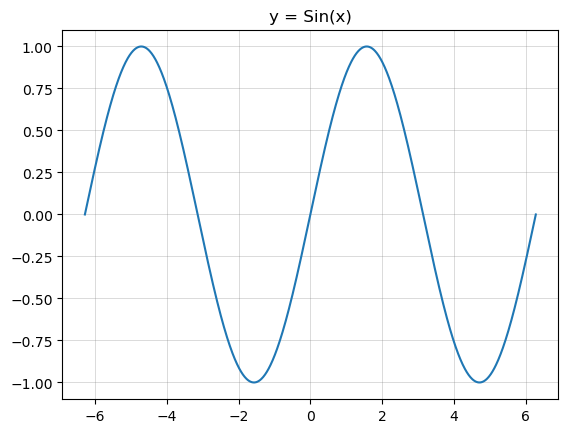

In [99]:
# Import plot from matplotlib
import matplotlib.pyplot as plt

x = np.linspace(-2*np.pi, 2*np.pi, num=1000)
y = np.sin(x)

# plot
plt.plot(x, y)
plt.title("y = Sin(x)")
plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5, alpha=0.4) # Draw a grid
plt.show()

### <font color='grey'> Chapter 2: NumPy (Part II : 2D Arrays)</font>

In [101]:
# Creating a 2D array
sales_data = [
    [120, 150, 190],  # Store 0
    [85,  95,  110],  # Store 1
    [210, 240, 280],  # Store 2
    [160, 175, 180]   # Store 3
]

S = np.array(sales_data)
print(S)
print(S.ndim)

[[120 150 190]
 [ 85  95 110]
 [210 240 280]
 [160 175 180]]
2


### Shape of the array

In [102]:
print(S.shape)

(4, 3)


### Accessing an element on a particular row or column

In [103]:
# method I
print(S[1,1])

# method II
print(S[1][1])

95
95


### Slicing arrays

In [108]:
# Array slicing
subS = S[0:3, 0:2]
print(subS)

[[120 150]
 [ 85  95]
 [210 240]]
